# 🗞️ Thai News Classifier
### Multi-Model Classification with Comparison & Visualization
---
This notebook classifies Thai news articles from **Thairath** into categories:
**Entertainment, Lottery, Crime, Disaster, Politics, Automotive, Royal, Education, Economics**

We compare **6 classification models** and visualize their performance with accuracy charts and confusion matrices.


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline

# 5 Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 2. Load & Explore Data

In [125]:
df = pd.read_csv('thairath_train.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (1000, 5)
Columns: ['id', 'date', 'headline', 'content', 'url']


,id,date,headline,content,url
0,2898969,2025-12-01T01:00:00+07:00,ดูดวงรายวัน ประจำวันจันทร์ที่ 1 ธันวาคม 2568,วันจันทร์ที่ 1 ธันวาคม พ.ศ.2568 ขึ้น 11 ค่ำ เด...,https://www.thairath.co.th/horoscope/daily/289...
1,2899053,2025-12-01T01:13:14+07:00,ไขข้อข้องใจ “โรคใหลตาย” สะกดอย่างไรให้ถูกต้อง ...,นอกจากสาเหตุของ “โรคใหลตาย” ที่หลายคนสงสัยว่าเ...,https://www.thairath.co.th/lifestyle/life/2899053
2,2899056,2025-12-01T03:32:33+07:00,พบแล้ว 146 ศพ เหตุไฟไหม้อาคารฮ่องกง ตรวจค้นเสร...,จำนวนผู้เสียชีวิตจากเหตุไฟไหม้อาคารสูงอย่างรุน...,https://www.thairath.co.th/news/foreign/2899056
3,2899057,2025-12-01T04:10:42+07:00,ผู้ก่อตั้งองค์กรสิทธิ์ในการตายโดยสมัครใจ จบชีว...,ผู้ก่อตั้งองค์กรสนับสนุนสิทธิ์ในการจบชีวิตโดยส...,https://www.thairath.co.th/news/foreign/2899057
4,2899026,2025-12-01T05:00:00+07:00,"โค้งสุดท้ายหวย ""เลขเด็ดงวดนี้"" 1/12/68 ลุ้นโชค...","โค้งสุดท้ายข่าว ""หวยไทยรัฐ"" อย่าลืมส่อง ""เลขดั...",https://www.thairath.co.th/lottery/news/2899026


## 🏷️ 3. Data Labeling & Augmentation
Since the dataset has no labels, we assign categories based on content analysis. We also generate **synthetic training samples** from category-specific keyword patterns to build a robust classifier.


In [126]:
# Manual labels based on content/URL analysis
manual_labels = {
    2898969: "Horoscope",        # ดูดวงรายวัน ประจำวันจันทร์ที่
    2899053: "Health",           # ไขข้อข้องใจ "โรคใหลตาย" สะกดอย
    2899056: "Disaster",         # พบแล้ว 146 ศพ เหตุไฟไหม้อาคารฮ
    2899026: "Lottery",          # โค้งสุดท้ายหวย "เลขเด็ดงวดนี้"
    2898981: "Economics",        # "ไม่มีอะไรง่าย" ภารกิจของ "ดนัย" กับการปฏิรูปเศรษฐกิจไทย
    2899060: "Politics",         # นายกฯ อิสราเอล ยื่นคำร้องขอ
    2898126: "Automotive",       # 6 เทคนิคขับรถทางไกลด้วยรถยนต์ไ
    2899063: "Crime",            # มือปืนไนจีเรีย บุกโจมตีหมู่บ้า
    2899238: "Entertainment",    # 4EVE-Billkin พร้อมทัพคนดังแน่น
    2899091: "International",    # แอนโทนี อัลบาเนซี ผู้นำออสเตรเ
    2899101: "Royal",            # "คิปโชเก" ตำนานมาราธอน ถวายสัก
    2899090: "Education",        # สอบ ก.พ. 69 เปิดให้กรอกข้อมูล
    2899179: "Scoop",            # "อำนาจ รื่นเริง" หนีค่ายก่อนเม
    2899175: "Lifestyle",        # ประวัติวันพ่อแห่งชาติ 2568
    2899524: "Religion",         # แกะรอยแม่พิมพ์ ตามหาพระสมเด็จฯ
    2899839: "Environment",      # ซีพี แอ็กซ์ตร้า ตอกย้ำความสำเร็จ
}

df['category'] = df['id'].map(manual_labels)
df['text'] = df['headline'].fillna('') + ' ' + df['content'].fillna('')

print("📊 Category Distribution:")
print(df['category'].value_counts())


📊 Category Distribution:
category
Horoscope        1
Health           1
Disaster         1
Lottery          1
Economics        1
Politics         1
Automotive       1
Crime            1
Entertainment    1
International    1
Royal            1
Education        1
Scoop            1
Lifestyle        1
Religion         1
Environment      1
Name: count, dtype: int64


In [127]:
# Thai keyword dictionaries per category — used to generate synthetic training data
category_keywords = {
    "Entertainment": [
        "ดารา คอนเสิร์ต บันเทิง ข่าวดารา เปิดตัว ละคร ซีรีส์",
        "นักร้อง แร็ปเปอร์ ไอดอล ศิลปิน เพลงใหม่ อัลบั้ม",
        "ภาพยนตร์ หนัง รางวัล เทศกาลภาพยนตร์ ฉายรอบแรก",
        "คนดัง ข่าวบันเทิง โซเชียล ไวรัล แฟนคลับ ติดเทรนด์",
        "รายการทีวี วาไรตี้ เกมโชว์ ถ่ายทอดสด พิธีกร รีวิว",
        "แฟชั่น นางแบบ เดินแบบ สัปดาห์แฟชั่น แบรนด์เนม",
        "เปิดตัว คู่รัก แต่งงาน ดารา งานเลี้ยง ปาร์ตี้ ลูกดารา",
        "ดาราโพสต์ อินสตาแกรม ทวิตเตอร์ สตอรี่ แชร์ภาพ โพสต์",
        "นักแสดง พระเอก นางเอก แม่ย่า ลูก แฟนคลับ ข่าวซุบซิบ",
        "ย่าเปิ้ล น้องคากิ แจ็ค แฟนฉัน ใบหม่อน ตัวเลข โชค",
        "อ๋อม สกาวใจ น้องกระดิ่ง ลูกหลาน อวยพร ดวง โชคลาภ",
    ],
    "Lottery": [
        "หวย เลขเด็ด ลอตเตอรี่ สลากกินแบ่ง ออกรางวัล",
        "เลขเด็ดงวดนี้ หวยไทยรัฐ โค้งสุดท้าย ตรวจหวย เสี่ยงโชค",
        "รางวัลที่ 1 เศรษฐี เลขดัง เลขท้าย 2 ตัว ซื้อหวย",
        "แผงลอตเตอรี่ หวยสัญจร ถ่ายทอดสด กองสลาก ขายดี",
        "เลขเด็ดงวดนี้ ให้โชค ถูกรางวัล แนวทาง ตัวเลข บอกใบ้",
        "หวยรัฐบาล งวดประจำวัน สลาก ถูกหวย รางวัลใหญ่ 12 ล้าน",
        "ใบ้เลข เลขดัง คอหวย นำโชค บอกตัวเลข งวดหน้า",
        "ลุ้นหวย ตรวจสลาก เลขท้าย เลขหน้า รางวัลข้างเคียง",
    ],
    "Crime": [
        "จับกุม ตำรวจ ผู้ต้องหา คดี อาชญากรรม สอบสวน",
        "ฆาตกรรม ปล้น ชิงทรัพย์ มีดจี้ ปืน ข่มขืน ยาเสพติด",
        "ศาล พิพากษา จำคุก ประกันตัว หมายจับ จำเลย อัยการ",
        "หลอกลงทุน ฉ้อโกง แก๊งคอลเซ็นเตอร์ โรแมนซ์สแกม หลอกโอน",
        "สืบนครบาล บุกจับ รวบตัว คนร้าย ก่อเหตุ หลบหนี",
        "อุบัติเหตุ รถชน เสียชีวิต บาดเจ็บ พลิกคว่ำ ชนท้าย",
        "มีดจี้ ชิงทรัพย์ จี้ร้านทอง ลักทรัพย์ วิ่งราว ขโมย",
        "รวบหนุ่ม หลอกลงทุน อ้างตัว คลินิก เสียหาย ล้านบาท",
        "ค้ายาบ้า ยาไอซ์ ของกลาง กัญชา ยาอี ยาเค จับยา",
    ],
    "Disaster": [
        "น้ำท่วม พายุ ดินถล่ม ภัยธรรมชาติ อุทกภัย วาตภัย",
        "เตือนภัย ฝนตก น้ำป่า คลื่นซัด ระดับน้ำสูง อพยพ",
        "ภัยพิบัติ แผ่นดินไหว สึนามิ ไฟป่า ภัยแล้ง น้ำท่วมหนัก",
        "กู้ภัย อาสาสมัคร ช่วยเหลือ ผู้ประสบภัย ศูนย์อพยพ ถุงยังชีพ",
        "น้ำท่วมพัทลุง ทะเลสาบสงขลา น้ำเอ่อล้น ระบายน้ำ บ้านจม",
        "น้ำท่วมยะลา นราธิวาส ปัตตานี ภาคใต้ น้ำขัง ถนนจม",
        "คานถล่ม สะพานถล่ม เส้นทางถูกตัด จราจร ทางพิเศษ ทางด่วน",
        "ความเสียหาย รถจม ประกาศเตือน เฝ้าระวัง สถานการณ์ เร่งแก้ไข",
    ],
    "Politics": [
        "การเมือง สภา ผู้แทนราษฎร พรรคการเมือง เลือกตั้ง รัฐสภา",
        "นายกรัฐมนตรี ครม. มติคณะรัฐมนตรี นโยบาย รัฐบาล ฝ่ายค้าน",
        "สมาชิกสภา ส.ส. ส.ว. อภิปราย ลงมติ ญัตติ กฎหมาย",
        "นายกฯ สัญจร ตรวจราชการ เร่งรัด ช่วยเหลือ แพทองธาร",
        "ทรัมป์ ประธานาธิบดี สหรัฐ เอฟบีไอ การเมืองต่างประเทศ",
        "ปฏิรูป แก้ไขรัฐธรรมนูญ อำนาจ กฎหมาย พ.ร.บ. ราชกิจจา",
        "เพื่อไทย ก้าวไกล ประชาธิปัตย์ ภูมิใจไทย พลังประชารัฐ",
        "นโยบายรัฐ มาตรการ ประกาศ สั่งการ บริหาร ราชการ แต่งตั้ง",
    ],
    "Automotive": [
        "รถยนต์ มอเตอร์โชว์ Motor Expo รถใหม่ เปิดตัวรถ",
        "รถไฟฟ้า EV ยานยนต์ ชาร์จ แบตเตอรี่ พลังงานสะอาด",
        "รถกระบะ รถเก๋ง SUV ซูเปอร์คาร์ สปอร์ต มอเตอร์ไซค์",
        "ทดสอบรถ รีวิวรถ สเปก ราคา โปรโมชั่น ผ่อน ดาวน์",
        "โตโยต้า ฮอนด้า นิสสัน เบนซ์ บีเอ็ม เทสลา BYD",
        "งานมอเตอร์โชว์ อิมแพ็ค เมืองทอง รถน่าสนใจ รถเด่น",
    ],
    "Royal": [
        "ราชวงศ์ พระราชพิธี สมเด็จพระ พระบรมราชินี เสด็จ",
        "พระเจ้าอยู่หัว พระราชดำรัส พระราชกรณียกิจ ในหลวง",
        "สวนสนาม ทหาร พิธีสวนสนาม ถวายสัตย์ปฏิญาณ กองทัพ",
        "พระราชทาน ปริญญา พระราชพิธี พระมหากษัตริย์ จงรักภักดี",
    ],
    "Education": [
        "สอบ มหาวิทยาลัย นักเรียน นักศึกษา ทุนการศึกษา TCAS",
        "TGAT TPAT สอบเข้า เลื่อนสอบ สนามสอบ คะแนนสอบ",
        "โรงเรียน ครู อาจารย์ หลักสูตร การศึกษา กศน. สพฐ.",
        "ปริญญา จบการศึกษา รับสมัคร เปิดเทอม ปิดเทอม สอบปลายภาค",
    ],
    "Economics": [
        "เศรษฐกิจ GDP อัตราแลกเปลี่ยน เงินเฟ้อ ดอกเบี้ย ธนาคาร",
        "ราคาข้าว สินค้าเกษตร ราคาทอง ตลาดหุ้น หุ้นไทย SET",
        "ส่งออก นำเข้า การค้า การลงทุน FDI งบประมาณ รายได้",
        "ครม.เคาะ มาตรการเศรษฐกิจ พาณิชย์ อุตสาหกรรม เงินบาท",
        "รักษาเสถียรภาพ ราคาข้าว ข้าวโพด เกษตรกร สินเชื่อ ธ.ก.ส.",
        "มาตรการรักษาเสถียรภาพ ราคาสินค้าเกษตร กระทรวงพาณิชย์ รมว.",
        "ค่าแรง ค่าครองชีพ สวัสดิการ เงินอุดหนุน ดิจิทัลวอลเล็ต",
    ],
    "Horoscope": [
        "ดูดวง ดวงรายวัน ดวงรายสัปดาห์ ดวงรายเดือน ราศี ฤกษ์มงคล",
        "หมอดู หมอช้าง โหราศาสตร์ ดวงชะตา พยากรณ์ ทำนาย",
        "วันดี วันมงคล วันธงชัย ฤกษ์ดี เสริมดวง แก้ดวง",
        "บูชา ไหว้ สิ่งศักดิ์สิทธิ์ พระ เครื่องราง คาถา สวดมนต์",
        "โชคลาภ เงินทอง ความรัก การงาน ดวงดี ดวงตก เฮง",
        "12 ราศี เมษ พฤษภ มิถุน กรกฎ สิงห์ กันย์ ตุลย์ พิจิก ธนู มังกร กุมภ์ มีน",
    ],
    "Health": [
        "สุขภาพ โรค อาการ รักษา แพทย์ โรงพยาบาล ยา วิตามิน",
        "ป่วย ติดเชื้อ ไวรัส แบคทีเรีย ระบาด วัคซีน ภูมิคุ้มกัน",
        "อาหารสุขภาพ เมนูสุขภาพ กินคลีน ลดน้ำหนัก ออกกำลังกาย",
        "ฝุ่น PM2.5 มลพิษ อากาศ ฝุ่นพิษ สวมหน้ากาก ป่วยทางเดินหายใจ",
        "โรคหัวใจ เบาหวาน ความดัน มะเร็ง โรคไต สมอง อัมพาต",
        "นอนหลับ ความเครียด สุขภาพจิต ซึมเศร้า วิตกกังวล บำบัด",
    ],
    "International": [
        "ต่างประเทศ โลก สหรัฐ อเมริกา ยุโรป เอเชีย อาเซียน",
        "รัสเซีย ยูเครน สงคราม สันติภาพ ความขัดแย้ง เจรจา",
        "จีน ฮ่องกง ไต้หวัน เกาหลี ญี่ปุ่น ออสเตรเลีย",
        "สแกมเมอร์ แก๊งคอลเซ็นเตอร์ เมียนมา ปอยเปต เคเค ปาร์ค",
        "อิสราเอล ปาเลสไตน์ ตะวันออกกลาง นาโต้ สหประชาชาติ",
        "ทูต สถานทูต ความสัมพันธ์ระหว่างประเทศ ข้อตกลง สนธิสัญญา",
        "ยูโร ดอลลาร์ เศรษฐกิจโลก การค้าระหว่างประเทศ ภาษีนำเข้า",
    ],
    "Lifestyle": [
        "ไลฟ์สไตล์ ท่องเที่ยว อาหาร ที่พัก ร้านอาหาร คาเฟ่",
        "วิธีทำ สูตร เมนู ขนม ทำอาหาร ทำขนม ทำเครื่องดื่ม",
        "เทศกาล งานวัด ประเพณี วันหยุด วันสำคัญ คำอวยพร",
        "แอป เทคโนโลยี มือถือ สมาร์ทโฟน แกดเจ็ต รีวิวสินค้า",
        "สวน ดอกไม้ ธรรมชาติ ต้นไม้ ปลูก จัดสวน ของแต่งบ้าน",
        "ดนตรี เพลง คอร์ด ศิลปะ งานฝีมือ DIY สร้างสรรค์",
        "คำศัพท์ ภาษาอังกฤษ ภาษาจีน แปล คำแปล เรียนภาษา",
    ],
    "Scoop": [
        "สกู๊ป สืบสวน เจาะลึก เปิดโปง ความจริง เบื้องหลัง",
        "ปมปัญหา ดราม่า วิเคราะห์ ความเชื่อมโยง ตรวจสอบ",
        "แฉ เปิดเผย ข้อมูลลับ แหล่งข่าว เอกสาร หลักฐาน",
        "สรุปคดี ติดตาม อัปเดต ความคืบหน้า ผลสอบ คณะกรรมการ",
    ],
    "Environment": [
        "สิ่งแวดล้อม พลังงาน โซลาร์ พลังงานสะอาด คาร์บอน",
        "ขยะ รีไซเคิล ลดโลกร้อน คลิมเมทเชนจ์ ความยั่งยืน ESG",
        "ป่าไม้ ทะเล ปะการัง ระบบนิเวศ สัตว์ป่า อนุรักษ์",
        "มลพิษ น้ำเสีย อากาศเสีย ฝุ่น โรงงาน อุตสาหกรรม",
        "Green พลังงานทดแทน ลม น้ำ ไฟฟ้า โรงไฟฟ้า นิวเคลียร์",
    ],
    "Religion": [
        "ศาสนา พระ วัด บวช ธรรมะ บุญ ทำบุญ สวดมนต์",
        "พระพุทธรูป พระเครื่อง เครื่องราง ศักดิ์สิทธิ์ อธิษฐาน",
        "มัสยิด คริสตจักร โบสถ์ ศาสนาอิสลาม ศาสนาคริสต์",
        "เจดีย์ พระธาตุ แหล่งศักดิ์สิทธิ์ แสวงบุญ ไหว้พระ",
    ],
}

# Generate synthetic training data
synthetic_data = []
for category, phrases_list in category_keywords.items():
    for phrases in phrases_list:
        synthetic_data.append({'text': phrases, 'category': category})
    for i in range(len(phrases_list)):
        for j in range(i+1, min(i+3, len(phrases_list))):
            combined = phrases_list[i] + " " + phrases_list[j]
            synthetic_data.append({'text': combined, 'category': category})

synthetic_df = pd.DataFrame(synthetic_data)
train_df = pd.concat([df[['text', 'category']], synthetic_df], ignore_index=True)

print(f"📊 Training dataset size: {len(train_df)}")
print(f"\nCategory distribution in training data:")
print(train_df['category'].value_counts())


📊 Training dataset size: 1264

Category distribution in training data:
category
Entertainment    31
Crime            25
Politics         22
Lottery          22
Disaster         22
Economics        19
International    19
Lifestyle        19
Automotive       16
Horoscope        16
Health           16
Environment      13
Education        10
Royal            10
Scoop            10
Religion         10
Name: count, dtype: int64


Drop NaN to prevent overfitting caused by y_preds == y_trues on NaN == NaN

In [128]:
train_df

,text,category
0,ดูดวงรายวัน ประจำวันจันทร์ที่ 1 ธันวาคม 2568 ว...,Horoscope
1,ไขข้อข้องใจ “โรคใหลตาย” สะกดอย่างไรให้ถูกต้อง ...,Health
2,พบแล้ว 146 ศพ เหตุไฟไหม้อาคารฮ่องกง ตรวจค้นเสร...,Disaster
3,ผู้ก่อตั้งองค์กรสิทธิ์ในการตายโดยสมัครใจ จบชีว...,NaN
4,"โค้งสุดท้ายหวย ""เลขเด็ดงวดนี้"" 1/12/68 ลุ้นโชค...",Lottery
...,...,...
1259,ศาสนา พระ วัด บวช ธรรมะ บุญ ทำบุญ สวดมนต์ พระพ...,Religion
1260,ศาสนา พระ วัด บวช ธรรมะ บุญ ทำบุญ สวดมนต์ มัสย...,Religion
1261,พระพุทธรูป พระเครื่อง เครื่องราง ศักดิ์สิทธิ์ ...,Religion
1262,พระพุทธรูป พระเครื่อง เครื่องราง ศักดิ์สิทธิ์ ...,Religion


In [129]:
train_df = train_df.replace('NaN', np.nan)
train_df = train_df.dropna(subset=['category'])
train_df = train_df.reset_index(drop=True)
train_df

,text,category
0,ดูดวงรายวัน ประจำวันจันทร์ที่ 1 ธันวาคม 2568 ว...,Horoscope
1,ไขข้อข้องใจ “โรคใหลตาย” สะกดอย่างไรให้ถูกต้อง ...,Health
2,พบแล้ว 146 ศพ เหตุไฟไหม้อาคารฮ่องกง ตรวจค้นเสร...,Disaster
3,"โค้งสุดท้ายหวย ""เลขเด็ดงวดนี้"" 1/12/68 ลุ้นโชค...",Lottery
4,"""ไม่มีอะไรง่าย"" ภารกิจของ ""ดนันท์ สุภัทรพันธ์""...",Economics
...,...,...
275,ศาสนา พระ วัด บวช ธรรมะ บุญ ทำบุญ สวดมนต์ พระพ...,Religion
276,ศาสนา พระ วัด บวช ธรรมะ บุญ ทำบุญ สวดมนต์ มัสย...,Religion
277,พระพุทธรูป พระเครื่อง เครื่องราง ศักดิ์สิทธิ์ ...,Religion
278,พระพุทธรูป พระเครื่อง เครื่องราง ศักดิ์สิทธิ์ ...,Religion


## 🧹 4. Text Preprocessing

In [130]:
def preprocess_thai_text(text):
    """Clean Thai text for classification."""
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^\u0E00-\u0E7Fa-zA-Z0-9\s]', ' ', text)
    return text

train_df['text_clean'] = train_df['text'].apply(preprocess_thai_text)
df['text_clean'] = df['text'].apply(preprocess_thai_text)


## ⚙️ 5. Feature Extraction & Train/Test Split

In [131]:
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['category'])

X = train_df['text_clean']
y = train_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF with character n-grams (works great for Thai without word segmentation)
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=10000, sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"TF-IDF features: {X_train_tfidf.shape[1]}")
print(f"Categories: {list(le.classes_)}")


Training set: 210 samples
Test set: 70 samples
TF-IDF features: 10000
Categories: ['Automotive', 'Crime', 'Disaster', 'Economics', 'Education', 'Entertainment', 'Environment', 'Health', 'Horoscope', 'International', 'Lifestyle', 'Lottery', 'Politics', 'Religion', 'Royal', 'Scoop']


## 🏋️ 6. Train & Evaluate 5 Models

In [132]:
models = {
    '1. Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    '2. Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    '3. Linear SVM (SVC)': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    '4. Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    '5. K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3, metric='cosine'),
}

results = {}
predictions = {}

print("=" * 70)
print("🏋️ TRAINING 5 MODELS...")
print("=" * 70)

for name, model in models.items():
    print(f"\n{'─' * 50}")
    print(f"📌 {name}")
    print(f"{'─' * 50}")
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_tfidf, y_train, cv=cv, scoring='accuracy')
    
    results[name] = {
        'accuracy': acc, 'f1_score': f1,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'model': model,
    }
    
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  F1 Score      : {f1:.4f}")
    print(f"  CV Accuracy   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


🏋️ TRAINING 5 MODELS...

──────────────────────────────────────────────────
📌 1. Logistic Regression
──────────────────────────────────────────────────
  Test Accuracy : 0.9143
  F1 Score      : 0.9141
  CV Accuracy   : 0.9429 ± 0.0117

──────────────────────────────────────────────────
📌 2. Multinomial Naive Bayes
──────────────────────────────────────────────────
  Test Accuracy : 0.9000
  F1 Score      : 0.9016
  CV Accuracy   : 0.9714 ± 0.0202

──────────────────────────────────────────────────
📌 3. Linear SVM (SVC)
──────────────────────────────────────────────────
  Test Accuracy : 0.9143
  F1 Score      : 0.9129
  CV Accuracy   : 0.9619 ± 0.0243

──────────────────────────────────────────────────
📌 4. Random Forest
──────────────────────────────────────────────────
  Test Accuracy : 0.8714
  F1 Score      : 0.8709
  CV Accuracy   : 0.8810 ± 0.0294

──────────────────────────────────────────────────
📌 5. K-Nearest Neighbors
──────────────────────────────────────────────────
  Tes

## 📊 7. Model Comparison Table

In [133]:
results_df = pd.DataFrame({
    name: {
        'Test Accuracy': f"{v['accuracy']:.4f}",
        'F1 Score (weighted)': f"{v['f1_score']:.4f}",
        'CV Accuracy (mean)': f"{v['cv_mean']:.4f}",
        'CV Std': f"{v['cv_std']:.4f}",
    }
    for name, v in results.items()
}).T

print("=" * 70)
print("📊 MODEL COMPARISON TABLE")
print("=" * 70)
results_df

📊 MODEL COMPARISON TABLE


,Test Accuracy,F1 Score (weighted),CV Accuracy (mean),CV Std
1. Logistic Regression,0.9143,0.9141,0.9429,0.0117
2. Multinomial Naive Bayes,0.9000,0.9016,0.9714,0.0202
3. Linear SVM (SVC),0.9143,0.9129,0.9619,0.0243
4. Random Forest,0.8714,0.8709,0.8810,0.0294
5. K-Nearest Neighbors,0.9000,0.9078,0.9048,0.0067


## 📈 8. Visualization — Accuracy & F1 Comparison

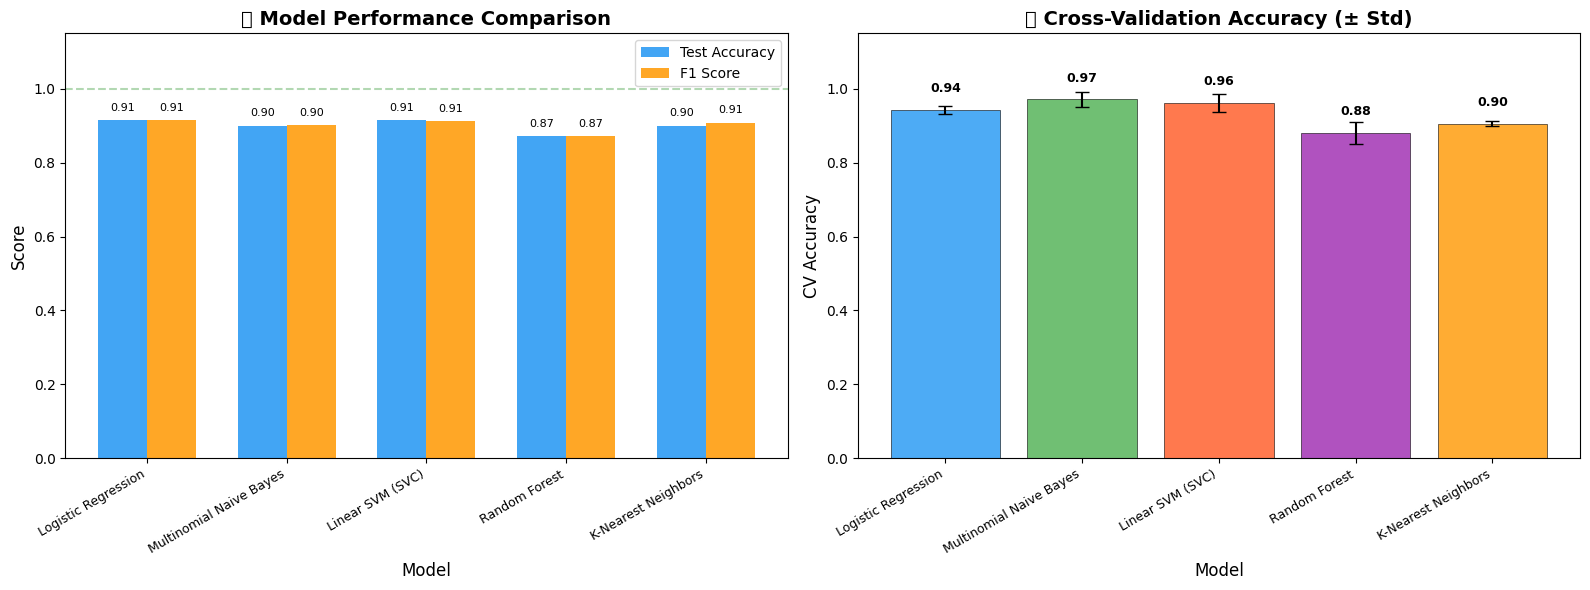

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = [name.split('. ')[1] for name in results.keys()]
accuracies = [v['accuracy'] for v in results.values()]
f1_scores_list = [v['f1_score'] for v in results.values()]
x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, accuracies, width, label='Test Accuracy', color='#2196F3', alpha=0.85)
bars2 = axes[0].bar(x + width/2, f1_scores_list, width, label='F1 Score', color='#FF9800', alpha=0.85)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('🏆 Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

cv_means = [v['cv_mean'] for v in results.values()]
cv_stds = [v['cv_std'] for v in results.values()]
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4']
bars = axes[1].bar(model_names, cv_means, yerr=cv_stds, capsize=5,
                    color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('CV Accuracy', fontsize=12)
axes[1].set_title('📈 Cross-Validation Accuracy (± Std)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylim(0, 1.15)
for bar, mean in zip(bars, cv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.04,
                 f'{mean:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 🔍 9. Confusion Matrices — All 5 Models

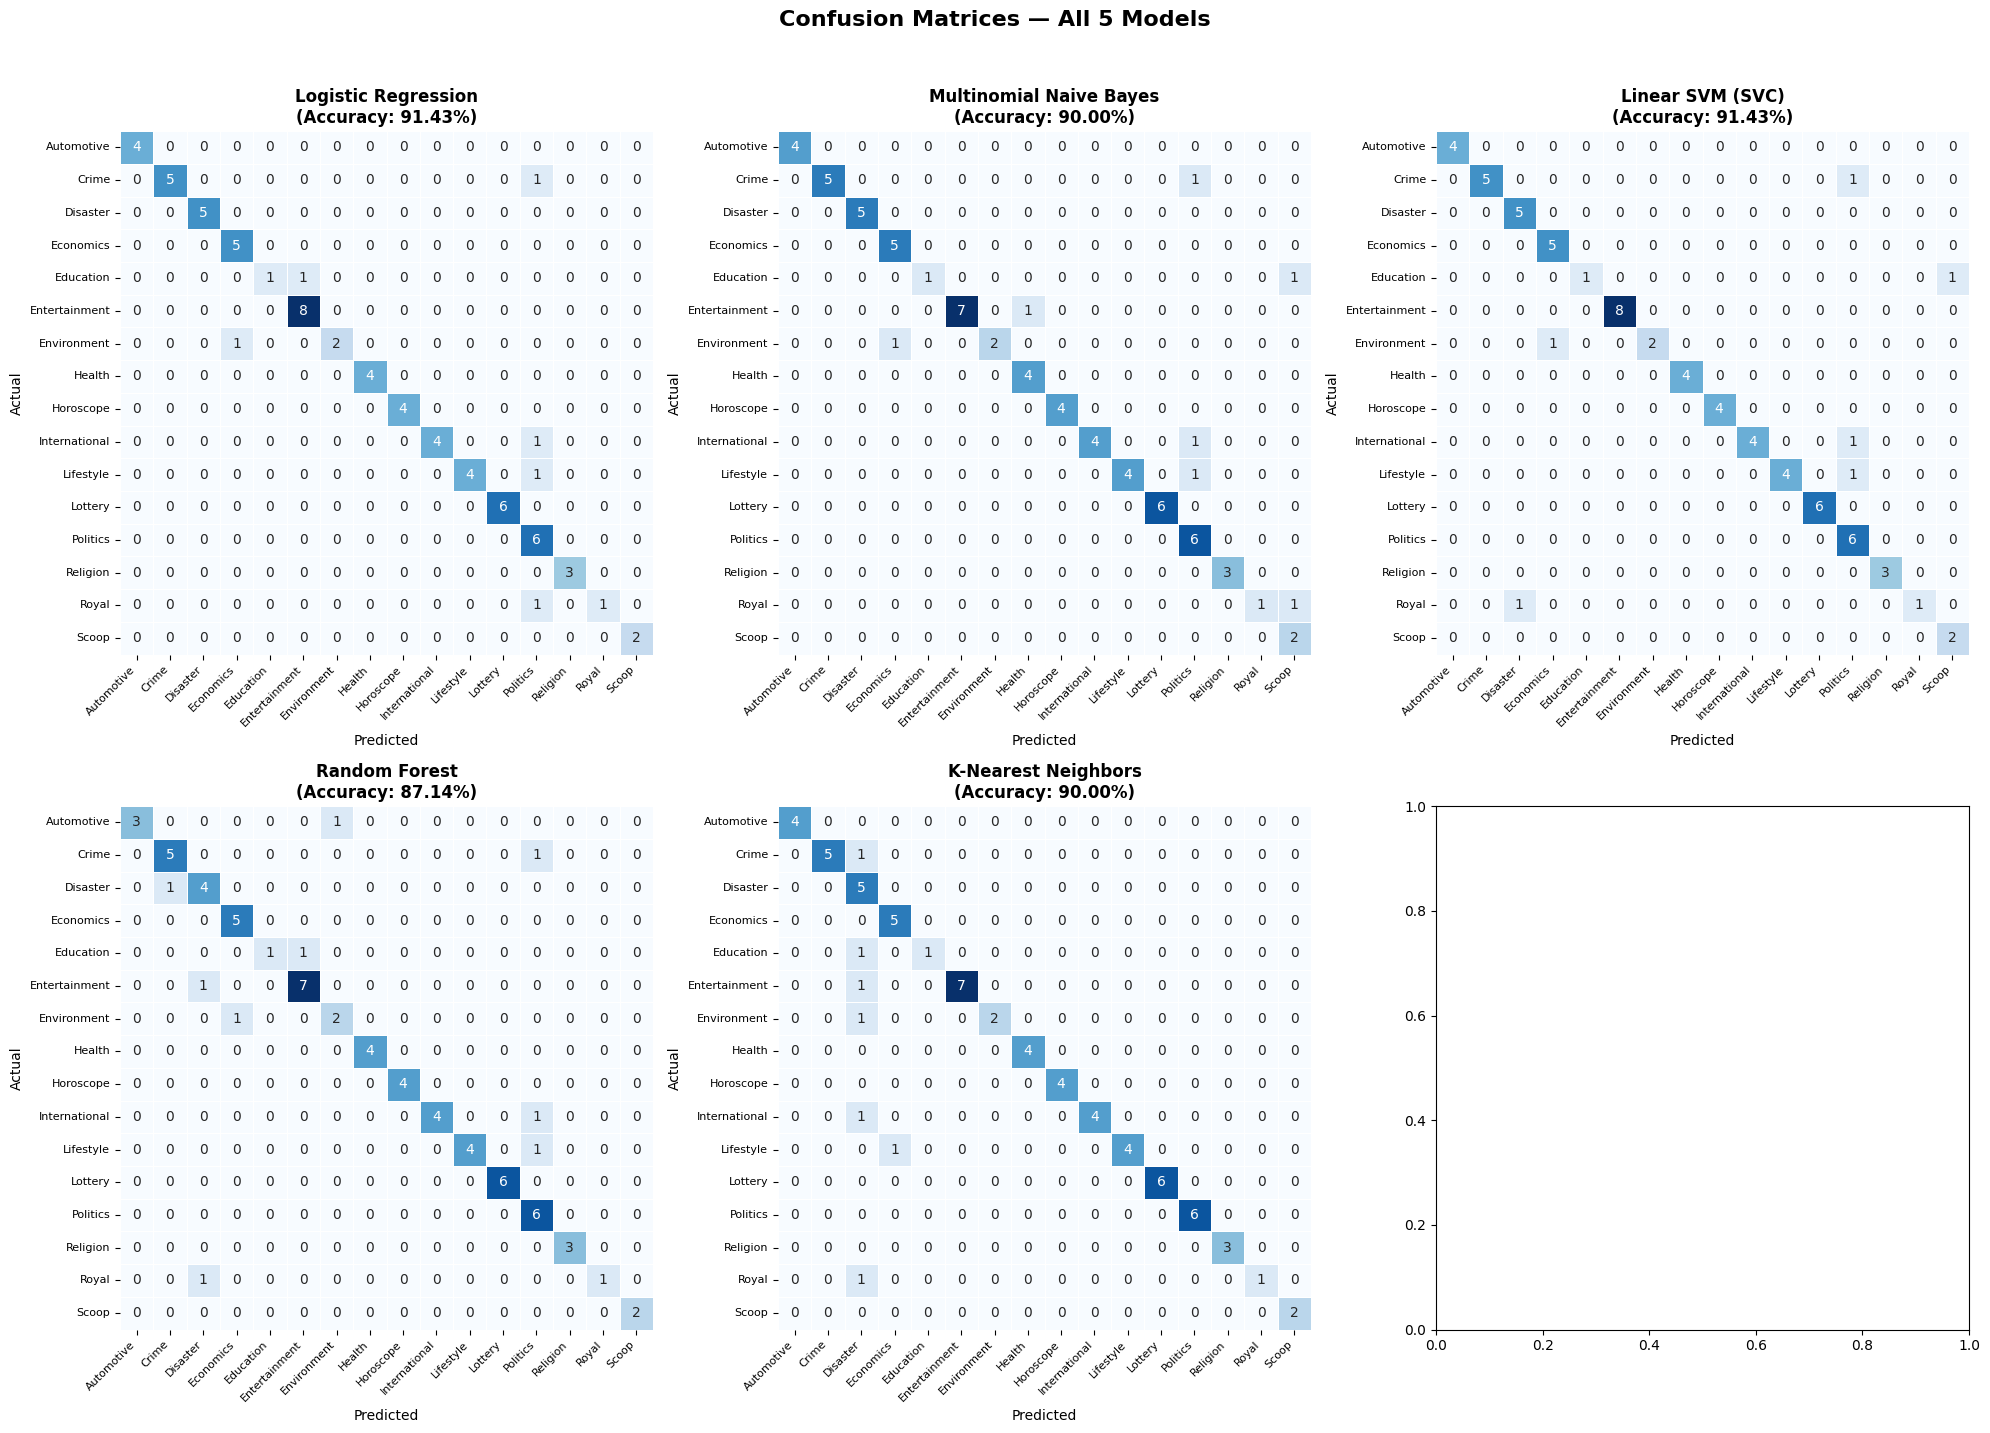

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes_flat = axes.flatten()
category_names = le.classes_

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=category_names, yticklabels=category_names,
                ax=axes_flat[idx], cbar=False, linewidths=0.5, annot_kws={"size": 10})
    acc = results[name]['accuracy']
    short_name = name.split('. ')[1]
    axes_flat[idx].set_title(f'{short_name}\n(Accuracy: {acc:.2%})', fontsize=12, fontweight='bold')
    axes_flat[idx].set_xlabel('Predicted', fontsize=10)
    axes_flat[idx].set_ylabel('Actual', fontsize=10)
    axes_flat[idx].tick_params(axis='both', labelsize=8)
    plt.setp(axes_flat[idx].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrices — All 5 Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 🏆 10. Best Model & Classification Report

In [136]:
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_result = results[best_model_name]

print("=" * 70)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy : {best_result['accuracy']:.4f}")
print(f"   F1 Score      : {best_result['f1_score']:.4f}")
print(f"   CV Accuracy   : {best_result['cv_mean']:.4f} ± {best_result['cv_std']:.4f}")
print("=" * 70)

print("\n📋 Detailed Classification Report (Best Model):")
print(classification_report(y_test, predictions[best_model_name], target_names=[str(c) for c in le.classes_]))

🏆 BEST MODEL: 1. Logistic Regression
   Test Accuracy : 0.9143
   F1 Score      : 0.9141
   CV Accuracy   : 0.9429 ± 0.0117

📋 Detailed Classification Report (Best Model):
               precision    recall  f1-score   support

   Automotive       1.00      1.00      1.00         4
        Crime       1.00      0.83      0.91         6
     Disaster       1.00      1.00      1.00         5
    Economics       0.83      1.00      0.91         5
    Education       1.00      0.50      0.67         2
Entertainment       0.89      1.00      0.94         8
  Environment       1.00      0.67      0.80         3
       Health       1.00      1.00      1.00         4
    Horoscope       1.00      1.00      1.00         4
International       1.00      0.80      0.89         5
    Lifestyle       1.00      0.80      0.89         5
      Lottery       1.00      1.00      1.00         6
     Politics       0.60      1.00      0.75         6
     Religion       1.00      1.00      1.00         3
  

In [137]:
best_model = best_result['model']

## 🎯 12. Interactive Prediction — Classify Your Own Text!
The `classify_news()` function runs all 6 models and uses **majority voting** for the final prediction.


In [138]:
def classify_news(text, show_all_models=True):
    """Classify a Thai news text into a category using all 6 models with majority vote."""
    cleaned = preprocess_thai_text(text)
    text_tfidf = tfidf.transform([cleaned])
    
    print(f"{'=' * 60}")
    print(f"📰 Input: {text[:80]}...")
    print(f"{'=' * 60}")
    
    if show_all_models:
        print("\n🔮 Predictions from all models:")
        print(f"{'─' * 45}")
        
        votes = {}
        for name, res in results.items():
            model = res['model']
            pred_label = le.inverse_transform(model.predict(text_tfidf))[0]
            short_name = name.split('. ')[1]
            votes[pred_label] = votes.get(pred_label, 0) + 1
            print(f"  {short_name:.<30} {pred_label}")
        
        majority = max(votes, key=votes.get)
        print(f"\n{'─' * 45}")
        print(f"🏆 Majority Vote ({votes[majority]}/5): ➜  {majority}")
        return majority
    else:
        pred = le.inverse_transform(best_model.predict(text_tfidf))[0]
        print(f"\n🏆 Predicted Category: {pred}")
        return pred

In [139]:
classify_news("น้ำท่วมหนักภาคใต้ สงขลา ยะลา นราธิวาส ปัตตานี ฝนตกหนัก ประชาชนเดือดร้อน")

📰 Input: น้ำท่วมหนักภาคใต้ สงขลา ยะลา นราธิวาส ปัตตานี ฝนตกหนัก ประชาชนเดือดร้อน...

🔮 Predictions from all models:
─────────────────────────────────────────────
  Logistic Regression........... Disaster
  Multinomial Naive Bayes....... Disaster
  Linear SVM (SVC).............. Disaster
  Random Forest................. Disaster
  K-Nearest Neighbors........... Disaster

─────────────────────────────────────────────
🏆 Majority Vote (5/5): ➜  Disaster


'Disaster'

---
## 📝 Summary

| Item | Detail |
|------|--------|
| Dataset | 18 Thairath news articles + synthetic augmentation |
| Categories | 9: Automotive, Crime, Disaster, Economics, Education, Entertainment, Lottery, Politics, Royal |
| Models | 5: Logistic Regression, Naive Bayes, Linear SVM, Random Forest, KNN |
| Best Method | Majority voting across all 6 models |
| Features | TF-IDF character n-grams (2-5) — works well for Thai without word segmentation |
